In [64]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

In [65]:
#Loading the dataset
file_path = 'sales_data_sample.csv'
data = pd.read_csv(file_path, encoding = 'latin1')

In [66]:
data.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


In [67]:
#displaying the first 10 rows of the dataset
data.head(10)


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium
5,10168,36,96.66,1,3479.76,10/28/2003 0:00,Shipped,4,10,2003,...,9408 Furth Circle,NaN,Burlingame,CA,94217,USA,NaN,Hirano,Juri,Medium
6,10180,29,86.13,9,2497.77,11/11/2003 0:00,Shipped,4,11,2003,...,"184, chausse de Tournai",NaN,Lille,NaN,59000,France,EMEA,Rance,Martine,Small
7,10188,48,100.00,1,5512.32,11/18/2003 0:00,Shipped,4,11,2003,...,"Drammen 121, PR 744 Sentrum",NaN,Bergen,NaN,N 5804,Norway,EMEA,Oeztan,Veysel,Medium
8,10201,22,98.57,2,2168.54,12/1/2003 0:00,Shipped,4,12,2003,...,5557 North Pendale Street,NaN,San Francisco,CA,NaN,USA,NaN,Murphy,Julie,Small
9,10211,41,100.00,14,4708.44,1/15/2004 0:00,Shipped,1,1,2004,...,"25, rue Lauriston",NaN,Paris,NaN,75016,France,EMEA,Perrier,Dominique,Medium


In [68]:
#checking the number of rows in the dataset
len(data) 

2823

In [69]:
#converting the 'ODERDATE' column to a datetime object and incase of a wrongly formatted date set it to NaT instaed of it causing an rror
data['ORDERDATE'] = pd.to_datetime(data['ORDERDATE'], errors = 'coerce')
#if a row has a a date that is NaT removes the row
data = data.dropna(subset=['ORDERDATE'])

In [70]:
#setting the 'ORDERDATE' column as the index inorder to resample the dataframe
monthly_sales = data.set_index('ORDERDATE').resample('ME')['SALES'].sum()

In [71]:
# converting the index to a column
df = monthly_sales.reset_index()
# renaming the columns to 'ds' and 'y'for the Prophet model
df.columns = ['ds', 'y']

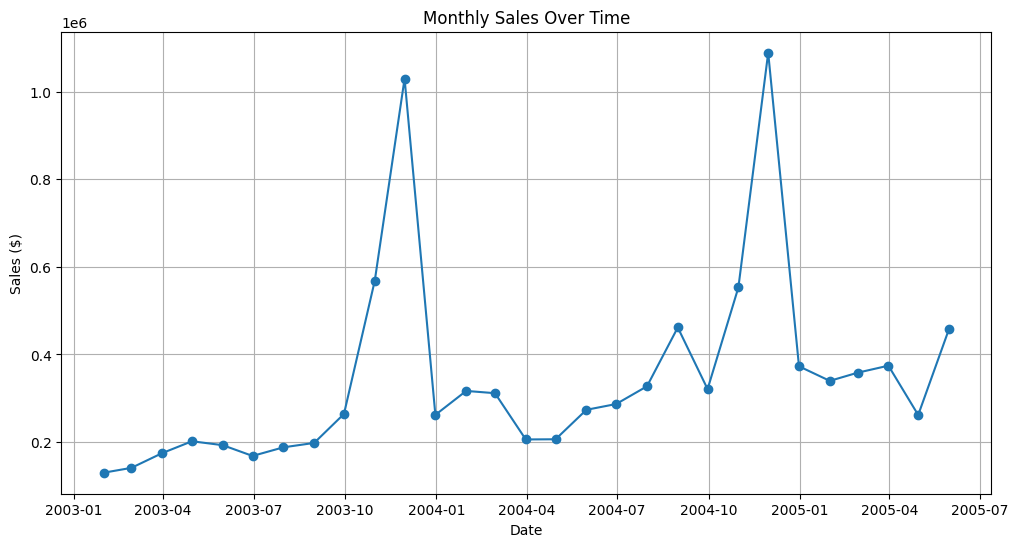

In [72]:
#plotting the data to visualize the sales over time
plt.figure(figsize=(12, 6))
plt.plot(df['ds'], df['y'], marker='o', linestyle='-')
plt.title('Monthly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.grid(True)
plt.show()

In [73]:
model = Prophet()
model.fit(df)
# Creating a future dataframe for the next 12 months
future = model.make_future_dataframe(periods=12, freq='ME')
forecast = model.predict(future)

22:54:20 - cmdstanpy - INFO - Chain [1] start processing
22:54:21 - cmdstanpy - INFO - Chain [1] done processing


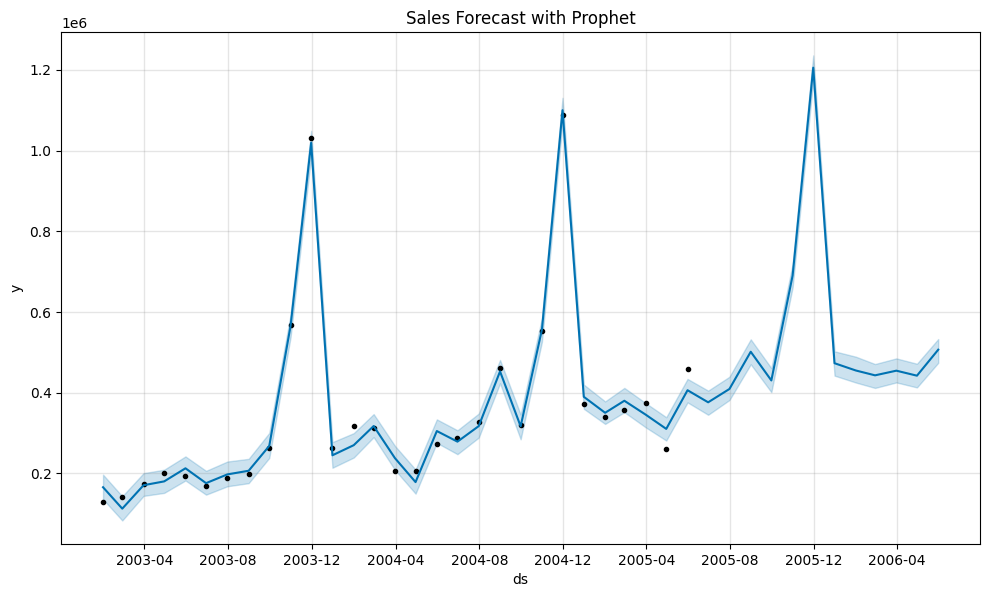

In [74]:
#plotting the actual data and the forecasted future data
fig1 = model.plot(forecast)
plt.title('Sales Forecast with Prophet')
plt.show()

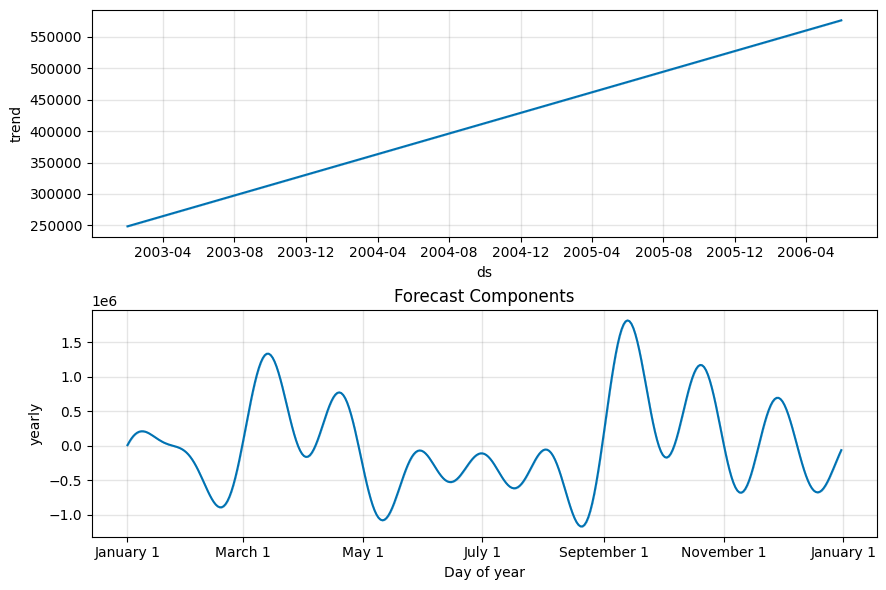

In [75]:
#plotting the overall trends and the yearly seasonality
fig2 = model.plot_components(forecast)
plt.title('Forecast Components')
plt.show()

CALCULATION OF THE MEAN ABSOLUTE PERCENTAGE ERROR AND ROOT MEAN SQUARED ERROR

In [76]:
merged = pd.merge(df, forecast[['ds', 'yhat']], on='ds', how='left')
merged = merged.dropna()
merged.head

<bound method NDFrame.head of            ds           y          yhat
0  2003-01-31   129753.60  1.657830e+05
1  2003-02-28   140836.19  1.127514e+05
2  2003-03-31   174504.90  1.707710e+05
3  2003-04-30   201609.55  1.802630e+05
4  2003-05-31   192673.11  2.127020e+05
5  2003-06-30   168082.56  1.759125e+05
6  2003-07-31   187731.88  1.975863e+05
7  2003-08-31   197809.30  2.066229e+05
8  2003-09-30   263973.36  2.681154e+05
9  2003-10-31   568290.97  5.651524e+05
10 2003-11-30  1029837.66  1.019105e+06
11 2003-12-31   261876.46  2.449672e+05
12 2004-01-31   316577.42  2.699817e+05
13 2004-02-29   311419.53  3.174059e+05
14 2004-03-31   205733.73  2.378781e+05
15 2004-04-30   206148.12  1.785288e+05
16 2004-05-31   273438.39  3.049997e+05
17 2004-06-30   286674.22  2.787313e+05
18 2004-07-31   327144.09  3.172435e+05
19 2004-08-31   461501.27  4.527048e+05
20 2004-09-30   320750.91  3.167240e+05
21 2004-10-31   552924.25  5.562035e+05
22 2004-11-30  1089048.01  1.099869e+06
23 2004-12

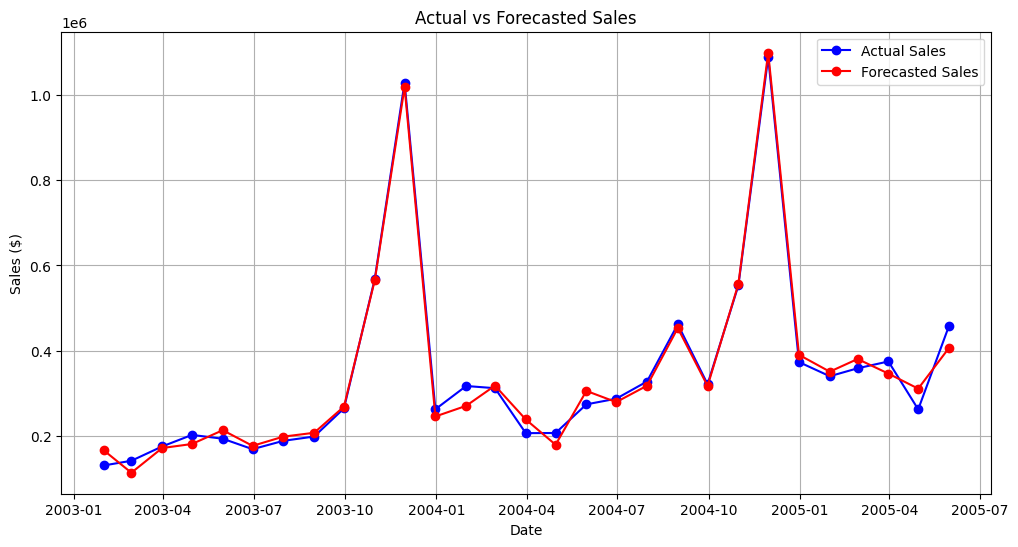

In [77]:
plt.figure(figsize=(12, 6))
plt.plot(merged['ds'], merged['y'], marker='o', linestyle='-', label='Actual Sales', color='blue')
plt.plot(merged['ds'], merged['yhat'], marker='o', linestyle='-', color='red', label='Forecasted Sales')
plt.title('Actual vs Forecasted Sales')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True)
plt.show()

In [78]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [79]:
mape = np.mean(np.abs((merged['y'] - merged['yhat']) / merged['y'])) * 100
print(f'MAPE: {mape:.2f}%')

MAPE: 7.38%


In [80]:
rmse = np.sqrt(mean_squared_error(merged['y'], merged['yhat']))
print(f'RMSE: {rmse:.2f}')

RMSE: 23305.54


In [81]:
r2 = r2_score(merged['y'], merged['yhat'])
print(f'R^2: {r2:.2f}')

R^2: 0.99
